# Figure 3: Decision variable prediction

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
cd "/app/"

/app


/usr/local/lib/python3.9/dist-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
%run env_aws.py
%run run.py connect

2025-06-10 08:51:39,571::INFO::settings.py::Setting loglevel to INFO
2025-06-10 08:51:39,572::INFO::settings.py::Setting stores to {}
2025-06-10 08:51:39,573::INFO::settings.py::Setting database.misc.schema_prefix to 
2025-06-10 08:51:39,574::INFO::settings.py::Setting database.misc.create_tables to True
2025-06-10 08:51:39,575::INFO::settings.py::Setting enable_python_native_blobs to True
2025-06-10 08:51:39,576::INFO::settings.py::Setting database.host to vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com
2025-06-10 08:51:39,577::INFO::settings.py::Setting database.user to thomas
2025-06-10 08:51:39,579::INFO::settings.py::Setting database.password to thomas_mathislab
2025-06-10 08:51:39,751::INFO::connection.py::Connected thomas@vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com:3306


Connecting thomas@vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com:3306


2025-06-10 08:51:39,859::INFO::table.py::could not log event in table ~log
2025-06-10 08:51:40,378::INFO::table.py::could not log event in table ~log
2025-06-10 08:51:40,378::INFO::table.py::could not log event in table ~log
2025-06-10 08:51:40,874::INFO::table.py::could not log event in table ~log
2025-06-10 08:51:40,874::INFO::table.py::could not log event in table ~log
2025-06-10 08:51:41,025::INFO::table.py::could not log event in table ~log
2025-06-10 08:51:41,025::INFO::table.py::could not log event in table ~log
2025-06-10 08:51:41,392::INFO::table.py::could not log event in table ~log
2025-06-10 08:51:41,392::INFO::table.py::could not log event in table ~log
2025-06-10 08:51:41,734::INFO::table.py::could not log event in table ~log
2025-06-10 08:51:41,734::INFO::table.py::could not log event in table ~log


In [9]:
from vr4mice.schema.base_analysis import DataFrame
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from vr4mice.analysis import plotting
from base_schemas.schemas.exp import Session
from vr4mice.schema import base_analysis
from vr4mice.analysis.analysis import style
from vr4mice.schema.interpolated_trajectories import InterpolatedTrials
from vr4mice.schema.session_metrics import TrialMetrics
from vr4mice.analysis import analysis
from vr4mice.schema import dlc
from vr4mice.analysis import utils
from vr4mice.analysis import regression

from statsmodels.stats.anova import AnovaRM
from scipy.stats import ttest_rel, ttest_ind
import scipy.stats as stats

style()

save_fig_path = "notebooks/Paper_figures/Figure_output/"

In [10]:
trial_df = (TrialMetrics() * vr4mice.Groups() * vr4mice.Labels() * (vr4mice.Dataset() & 'session_label = "ar_discrim_occluders"')).fetch(as_dict=True)
trial_df =  pd.concat([pd.DataFrame(x) for x in trial_df])
# Exclude sessions that were not in the list
trial_df, reward_table = utils.dual_occluder_inclusion_criteria(trial_df, return_excluded=False)
# Create list of included datasets
mouse_list = trial_df.dataset.unique()
trial_df["mouse_name"] = trial_df.dataset.str.split("_").str [0]

Excluded datasets:  ['31728_2025-03-05_1' '31728_2025-03-06_1' 'J729_2024-11-29_1'
 'J731_2024-12-04_1' 'J731_2024-12-06_1']


In [ ]:
# This takes a while to fetch because we need to fetch data for all trials (4 min 20 secs) 
dataset_list = []
for d in mouse_list:    
    print(d)
    try:
        if len(InterpolatedTrials() & f'dataset = "{d}"') > 0:
            dataset_list.append(pd.DataFrame((InterpolatedTrials() & f'dataset = "{d}"').fetch(as_dict=True)[0]))
        else:
            print("dataset missing")
    except Exception as err:
        print(err, " dataset missing")
interpolated_df = pd.concat(dataset_list)
interpolated_df ["mouse_name"] = interpolated_df.dataset.str.split("_").str [0]

31726_2025-03-18_1
dataset missing
31726_2025-03-19_1
dataset missing
31726_2025-03-20_1
dataset missing
31726_2025-03-21_1
dataset missing
31728_2025-03-07_1
dataset missing
31728_2025-03-20_1
dataset missing
31728_2025-03-21_1
dataset missing
J729_2024-11-30_1
dataset missing
J729_2024-12-01_1
dataset missing
J729_2024-12-02_1
dataset missing
J729_2024-12-03_1
dataset missing
J729_2024-12-04_1
dataset missing
J729_2024-12-10_1
dataset missing
J731_2024-12-05_1
dataset missing
J731_2024-12-09_1
dataset missing
Jacana_2024-08-13_1
dataset found
Jacana_2024-08-14_1
dataset found
Jacana_2024-08-15_1
dataset found
Jacana_2024-08-16_1
dataset found
Jacana_2024-08-19_1
dataset found
Kiwi_2024-08-10_2
dataset found
Kiwi_2024-08-11_4
dataset found
Kiwi_2024-08-12_2
dataset found
Kiwi_2024-08-13_1
dataset found
Kiwi_2024-08-14_1
dataset found
Lemming_2024-08-10_1
dataset found
Lemming_2024-08-11_1
dataset found
Lemming_2024-08-12_1
dataset found
Lemming_2024-08-13_1
dataset found
Nightingale_2

In [60]:
box_df = base_analysis.BoxDataFrame().get_data(key={"dataset": "Pheasant_2024-08-15_2"})


In [61]:
model_labels = regression.model_labels 

In [62]:
interpolated_df["aperture"] = interpolated_df["aperture"].astype(float)

df_model, coef = regression.predict_decision(
    df=interpolated_df, label=model_labels, per_mouse=True
)

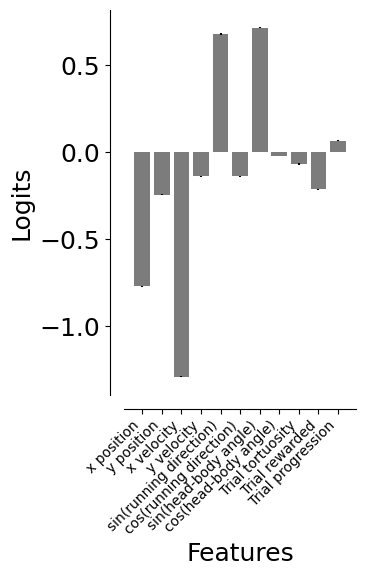

In [64]:
# Logits of the regression
fig, ax = plt.subplots(1, 1, figsize=(3, 5))
ax.bar(
    regression.model_labels,
    np.mean(coef[:, 1:], axis=0),
    yerr=stats.sem(coef[:, 1:], axis=0),
    color="#7C7C7C",
)
sns.despine(offset=10, ax=ax)

ax.set_xticks(np.arange(len(regression.model_labels)))
ax.set_xticklabels(regression.clean_model_labels, rotation=45, ha="right", fontsize=10)
ax.set_ylabel("Logits")
ax.set_xlabel("Features")

plt.savefig(save_fig_path + "figure3_dual_occluder_model_logits.svg", transparent=False)

Kiwi_2024-08-14_1


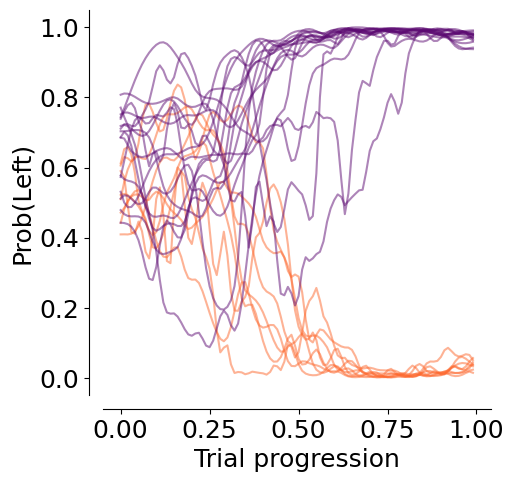

In [86]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

group = df_model[(df_model.dataset == "Kiwi_2024-08-14_1")]
print(df_model.dataset.unique()[9])

trials = [
    94,
    15,
    66,
    170,
    224,
    195,
    56,
    203,
    88,
    239,
    113,
    91,
    186,
    248,
    109,
    164,
    188,
    60,
    229,
    182,
    156,
    197,
    52,
    45,
]  # 110, 156, 190,  22, 210,  24,  51,  78,
# 239,  97,  24, 176, 168, 184, 123, 156]

group = group[group.trial.isin(np.array(trials))]
sns.lineplot(
    data=group,
    x="trial_length",
    y="proba_left",
    hue="trial_left_choice",
    errorbar=None,
    estimator=None,
    units="trial",
    palette=plotting.colors_choice[::-1],
    sort=False,
    alpha=0.5,
    ax=ax,
)
ax.set_ylabel("Prob(Left)")
ax.set_xlabel("Trial progression")
ax.legend([], [], frameon=False)
sns.despine(offset=10)

plt.savefig(
    save_fig_path + "figure3_dual_occluder_dynamic_decision_variable.svg",
    transparent=True,
)

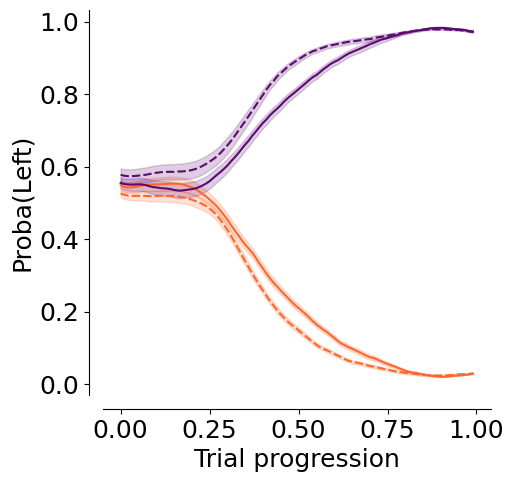

In [89]:
df_model_mean =  df_model.groupby(["dataset", "aperture", "trial_left_choice", "trial_length"], as_index=False).mean()
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
sns.lineplot(
    data=df_model_mean,
    x="trial_length",
    y="proba_left",
    hue="trial_left_choice",
    style="aperture",
    palette=plotting.colors_choice[::-1],
    sort=False,
    alpha=1,
    ax=ax,
    errorbar="se"
)
ax.set_ylabel("Proba(Left)")
ax.set_xlabel("Trial progression")
ax.legend([], [], frameon=False)
sns.despine(offset=10)
plt.savefig(
    save_fig_path + "figure3_dual_occluder_dynamic_decision_variable_avg.svg",
    transparent=True,
)

In [90]:
df_model_mean =  df_model.groupby(["dataset", "aperture", "trial_length"], as_index=False).mean()

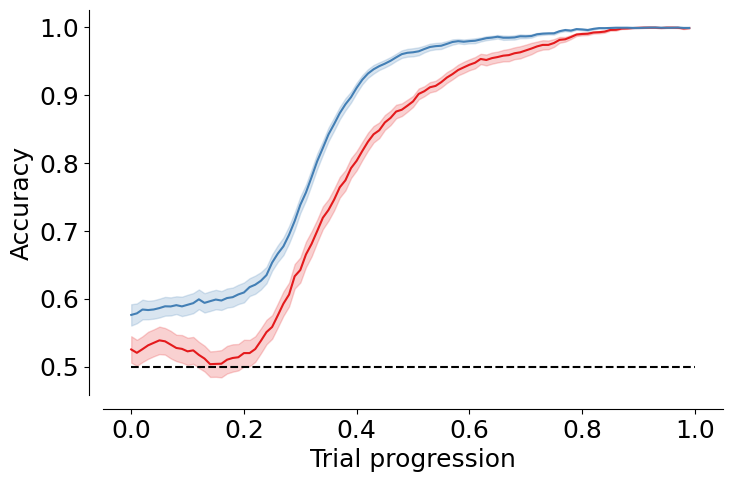

In [91]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
sns.lineplot(
    data=df_model_mean,
    x="trial_length",
    y="accuracy",
    hue="aperture",
    palette=plotting.colors_aperture,
    sort=False,
    alpha=1,
    ax=ax,
    errorbar="se"
)
ax.hlines(0.5, 0, 1, color="black", linestyle="--")

ax.set_ylabel("Accuracy")
ax.set_xlabel("Trial progression")
ax.legend([], [], frameon=False)
sns.despine(offset=10)

plt.savefig(
    save_fig_path + "figure3_dual_occluder_model_accuracy.svg", transparent=True
)

In [92]:
df_model["trial_length_bin"] = pd.cut(
    df_model["trial_length"], bins=50
)  # Adjust bins as needed
df_anova = df_model.groupby(
    ["dataset", "aperture", "trial_length_bin"], as_index=False
)["accuracy"].mean()

print(
    AnovaRM(
        data=df_anova,
        depvar="accuracy",
        subject="dataset",
        within=["aperture", "trial_length_bin"],
    ).fit()
)

                           Anova
                          F Value   Num DF   Den DF  Pr > F
-----------------------------------------------------------
aperture                   30.7877  1.0000   28.0000 0.0000
trial_length_bin          893.5326 49.0000 1372.0000 0.0000
aperture:trial_length_bin   9.9814 49.0000 1372.0000 0.0000



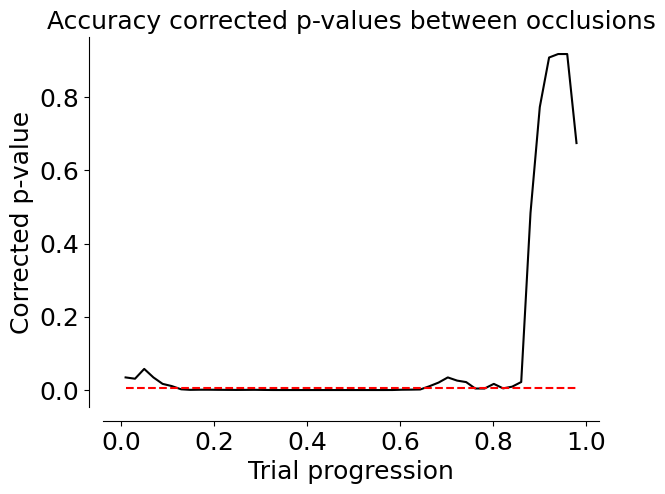

In [93]:
p_values = []
for i in df_anova.trial_length_bin.unique():
    section = df_anova[df_anova.trial_length_bin == i]
    t = ttest_ind(
        section[section.aperture == section.aperture.unique()[0]].accuracy,
        section[section.aperture == section.aperture.unique()[1]].accuracy,
    )
    p_values.append(pd.DataFrame({"segment": i, "p_value": t.pvalue}, index=[0]))

p_value_df = pd.concat(p_values)
p_value_df["p_value_corr"] = stats.false_discovery_control(p_value_df.p_value)

# Convert interval bins to numeric midpoints
p_value_df["segment"] = p_value_df["segment"].apply(lambda x: x.mid)

plt.plot(p_value_df.segment, p_value_df.p_value_corr, c="k")

plt.hlines(
    0.005,
    xmin=p_value_df.segment.min(),
    xmax=p_value_df.segment.max(),
    color="red",
    linestyle="dashed",
)

plt.xlabel("Trial progression")
plt.ylabel("Corrected p-value")
plt.title("Accuracy corrected p-values between occlusions")

sns.despine(offset=10)
plt.savefig(
    save_fig_path + "figure3_dual_occluder_model_accuracy_pvalue.svg", transparent=True
)

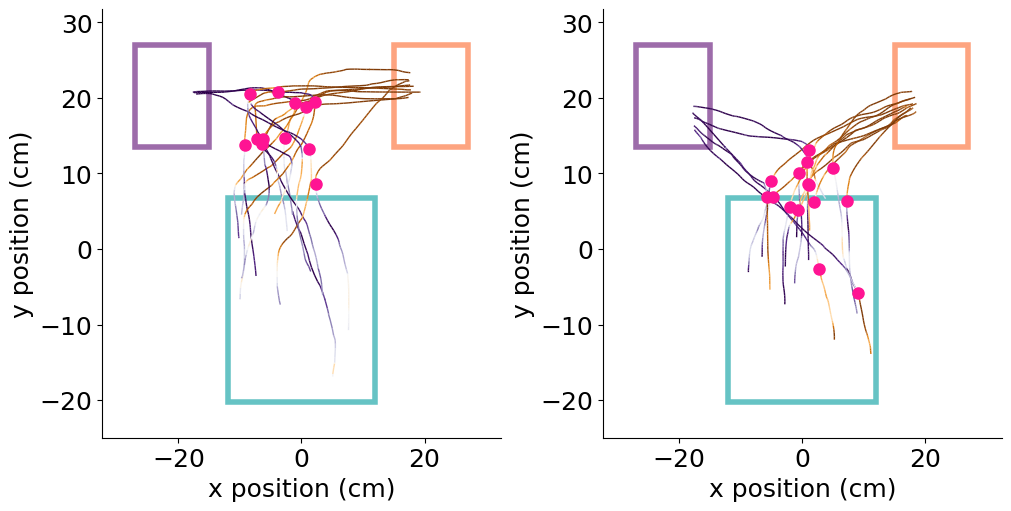

In [94]:
df_model["session"] = df_model["dataset"]
df_model["trial_L_choice"] = df_model["trial_left_choice"]
decision_points = regression.find_decision_point(df_model, threshold_uncertainty=0.3)
fig, ax = plt.subplots(
    1, len(df_model.aperture.unique()), figsize=(10, 5), constrained_layout=True
)

decision_color = "deeppink"
session_to_plot = "Pheasant_2024-08-15_2"
box_df = base_analysis.BoxDataFrame().get_data(key={"dataset": "Pheasant_2024-08-15_2"})

trials = [44, 45, 19, 62, 61, 45, 85, 41, 43, 41, 50, 75, 24, 69, 84, 74, 10] + [
    63,
    30,
    78,
    47,
    33,
    5,
    17,
    9,
    47,
    30,
    99,
    11,
    12,
    15,
]


for i, aperture in enumerate(df_model.aperture.unique()):
    regression.plot_decision_points_on_trajectory(
        df_model[
            (df_model.dataset == session_to_plot) & (df_model.aperture == aperture)
        ],
        box_df,
        decision_point=decision_points[
            (decision_points.dataset == session_to_plot)
            & (decision_points.aperture == aperture)
        ],
        color=decision_color,
        trials=trials,
        ax=ax[i],
    )
    ax[i].set_xlabel("x position (cm)")
    ax[i].set_ylabel("y position (cm)")
plt.savefig(
    save_fig_path + "figure3_dual_occluder_decision_points_trajectories.svg",
    transparent=True,
)

2025-06-10 10:00:39,476::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-06-10 10:00:39,476::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-06-10 10:00:39,484::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-06-10 10:00:39,484::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-06-10 10:00:39,549::INFO::category.py::Using categorical un

12.0-4.3: TtestResult(statistic=-9.246837041691345, pvalue=5.265343916148598e-10, df=28)


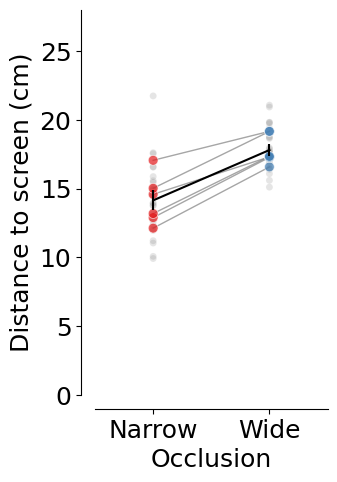

In [95]:
fig, ax = plt.subplots(1, 1, figsize=(3, 5))
stats = plotting.pairplot_average_decision_point(
    decision_points,
    label_parameter="y",
    ax=ax,
    cmap=plotting.colors_aperture,
    per_mouse=True,
)
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(0, 28)
ax.set_xlabel("Occlusion")
ax.set_xticks([0, 1], ["Narrow", "Wide"])
ax.set_ylabel("Distance to screen (cm)")
sns.despine(offset=10)
plt.legend([], [], frameon=False)

plt.savefig(
    save_fig_path + "figure3_dual_occluder_decision_points_distance.svg",
    transparent=True,
)

In [17]:
decision_points = decision_points.groupby(["dataset", "aperture"], as_index=False)[
    "y"
].mean()
anova_rm = AnovaRM(decision_points, depvar="y", subject="dataset", within=["aperture"])

anova_results = anova_rm.fit()
anova_table = anova_results.summary()
print(anova_table)

                Anova
         F Value Num DF  Den DF Pr > F
--------------------------------------
aperture 99.1809 1.0000 44.0000 0.0000



# below this is old code for loading from file - this has now been replaced

In [18]:
# parameter = "y"
# thresholds = [0.1, 0.3, 0.5, 0.7, 0.9] # that's the uncertainty threshold of the model
# diffs = []
# for i in thresholds:
#     decision_points = regression.find_decision_point(df_model, threshold_uncertainty=i)

#     aperture_means = decision_points.groupby(["mouse_name", "dataset", "aperture"]).mean().groupby(["aperture"]).mean()[parameter]
#     diffs.append(aperture_means.iloc[0] - aperture_means.iloc[-1])

# fig, ax = plt.subplots(1, 1, figsize=(5, 5))
# ax.plot(thresholds, diffs, color="k")
# ax.set_xlabel("Threshold")
# ax.set_ylabel("Diff distance to screen (cm)")

In [ ]:
# To be run with Figure 2 notebook, else see how to load the data in Figure 2 notebook
tolias = pd.read_pickle("big_df_contrast_tolias_new.pkl")
neil_df = pd.read_pickle("big_df_contrast_dual_niell.pkl")
mathis =  pd.read_pickle("dual_occluder_mathis_lab_all_sessions.pkl")

big_df = pd.concat([tolias, neil_df, mathis]).reset_index(drop=True)
big_df, reward_table = utils.dual_occluder_inclusion_criteria(big_df, return_excluded=False)

big_df = big_df[big_df.iti == 0.0]

interpolated_j_shaped = utils.interpolate_j_shaped(big_df, box_df, n_points=500)

Excluded datasets:  ['31728_2025-03-05_1' '31728_2025-03-06_1' 'J729_2024-11-29_1'
 'J731_2024-12-04_1' 'J731_2024-12-06_1']
